# **Week 8 Spatial Autocorrelation Analysis**
### **Jia Ni**
In this assignment, I incorporated the LA 2023 Bicycle Crashes data [TIMS](https://tims.berkeley.edu/tools/gismap/#), conducted a spatial autocorrelation analysis on bicycle crash density using both global and local Moran’s I statistics.

### **Import the libraries**

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import libpysal as ps
import esda
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import branca

In [2]:
# Read file
crashes = gpd.read_file("data/crashes_census_tract.geojson")
crashes. info(verbose=True, show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2498 entries, 0 to 2497
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   FIPS              2498 non-null   object  
 1   area_sq_km        2498 non-null   float64 
 2   crash_count       2498 non-null   float64 
 3   Total population  2498 non-null   int32   
 4   crash_density     2477 non-null   float64 
 5   geometry          2498 non-null   geometry
dtypes: float64(3), geometry(1), int32(1), object(1)
memory usage: 107.5+ KB


In [3]:
# Diversity index calculated in previous work
index = gpd.read_file("data/tracts_shannon_index.geojson")
index. info(verbose=True, show_counts=True)

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2477 entries, 0 to 2476
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   FIPS                  2477 non-null   object  
 1   Shannon_Wiener_Index  2477 non-null   float64 
 2   geometry              2477 non-null   geometry
dtypes: float64(1), geometry(1), object(1)
memory usage: 58.2+ KB


In [4]:
# Combine the diversity index and crash density across different census tracts
crashes_index = crashes.merge(index, on="FIPS", how="inner")
crashes_index = crashes_index.dropna(subset=["Shannon_Wiener_Index", "crash_density"])

crashes_index = crashes_index.rename(columns={'geometry_x': 'geometry'})
crashes_index = crashes_index.drop(columns=['geometry_y'])

crashes_index.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 2477 entries, 0 to 2476
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   FIPS                  2477 non-null   object  
 1   area_sq_km            2477 non-null   float64 
 2   crash_count           2477 non-null   float64 
 3   Total population      2477 non-null   int32   
 4   crash_density         2477 non-null   float64 
 5   geometry              2477 non-null   geometry
 6   Shannon_Wiener_Index  2477 non-null   float64 
dtypes: float64(4), geometry(1), int32(1), object(1)
memory usage: 125.9+ KB


In [5]:
# Check and ensure the data is in the correct projection
print(crashes_index.crs)

EPSG:4326


In [6]:
# Create a spatial weights matrix
w = ps.weights.Queen.from_dataframe(crashes_index)

# Normalize the weights
w.transform = "r"

/tmp/ipykernel_1296/392646994.py:2: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = ps.weights.Queen.from_dataframe(crashes_index)
/opt/conda/lib/python3.11/site-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [7]:
w = ps.weights.KNN.from_dataframe(crashes_index, k=4)
w.transform = "r"

### **Global Moran's I statistics**

In [8]:
# Compute Global Moran's I
moran = esda.moran.Moran(crashes_index["crash_density"], w)

print(f"Moran's I: {moran.I}, p-value: {moran.p_sim}")

Moran's I: 0.000298072229889115, p-value: 0.091


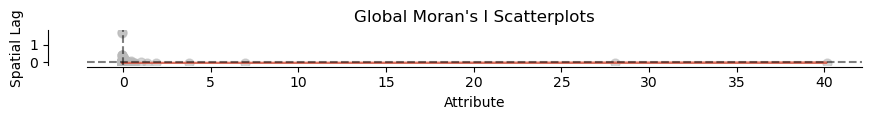

In [9]:
# Generate Moran's Plot
from splot.esda import moran_scatterplot

fig, ax = plt.subplots(figsize=(10, 8)) 
moran_scatterplot(moran, ax=ax, aspect_equal=True)
plt.title("Global Moran's I Scatterplots")
plt.show()

### **Interpretation**
- The Moran’s I statistic is 0.00029807, which suggests that there is almost no spatial autocorrelation in crash density.
- The p-value is 0.085 (>0.05), which means that there is not enough statistical evidence to reject the null hypothesis that crash density is randomly distributed.
- The almost flat scatter plot further confirms the lack of a clear spatial relationship between census tracts in terms of crash density.

In conlusion, there is no significant spatial clustering of bicycle crash density at the global level. The results suggest that crash density is randomly distributed rather than clustered in specific regions.

### **Local Moran's I statistics**

In [10]:
# Compute Local Moran's I (LISA) for spatial clustering analysis
lisa = esda.moran.Moran_Local(crashes_index["crash_density"], w)

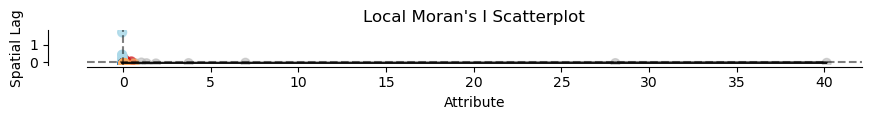

In [11]:
# Generate Local Moran’s I Moran Plot
import splot.esda as splot

fig, ax = plt.subplots(figsize=(10, 8))
splot.moran_scatterplot(lisa, p=0.05, ax=ax)
plt.title("Local Moran's I Scatterplot")
plt.show()

In [12]:
crashes_index["local_moran"] = lisa.Is
crashes_index["p_value"] = lisa.p_sim

crashes_index.head()

,FIPS,area_sq_km,crash_count,Total population,crash_density,geometry,Shannon_Wiener_Index,local_moran,p_value
0,06037101110,1.142400,0.0,4152,0.0,"POLYGON ((-118.29418 34.25595, -118.29434 34.2...",1.221241,0.003607,0.135
1,06037101122,2.644046,0.0,4198,0.0,"POLYGON ((-118.29567 34.26321, -118.29602 34.2...",0.919590,0.003607,0.135
2,06037101220,0.698884,0.0,3434,0.0,"POLYGON ((-118.28421 34.24792, -118.28593 34.2...",1.331101,0.003607,0.135
3,06037101221,0.354176,0.0,3931,0.0,"POLYGON ((-118.28862 34.2523, -118.2898 34.252...",1.379888,0.003607,0.135
4,06037101222,0.296513,0.0,2572,0.0,"POLYGON ((-118.28968 34.24908, -118.28983 34.2...",1.035838,0.003607,0.135


In [13]:
# Set significance threshold (e.g., p < 0.05)
sig = 0.05

# Create a new column to classify LISA clusters
crashes_index["LISA_Cluster"] = "NS"

# Identify significant clusters
significant = crashes_index["p_value"] < sig

# Define quadrant categories
crashes_index.loc[significant & (lisa.q == 1), "LISA_Cluster"] = "HH"
crashes_index.loc[significant & (lisa.q == 2), "LISA_Cluster"] = "LH"
crashes_index.loc[significant & (lisa.q == 3), "LISA_Cluster"] = "LL"
crashes_index.loc[significant & (lisa.q == 4), "LISA_Cluster"] = "HL"


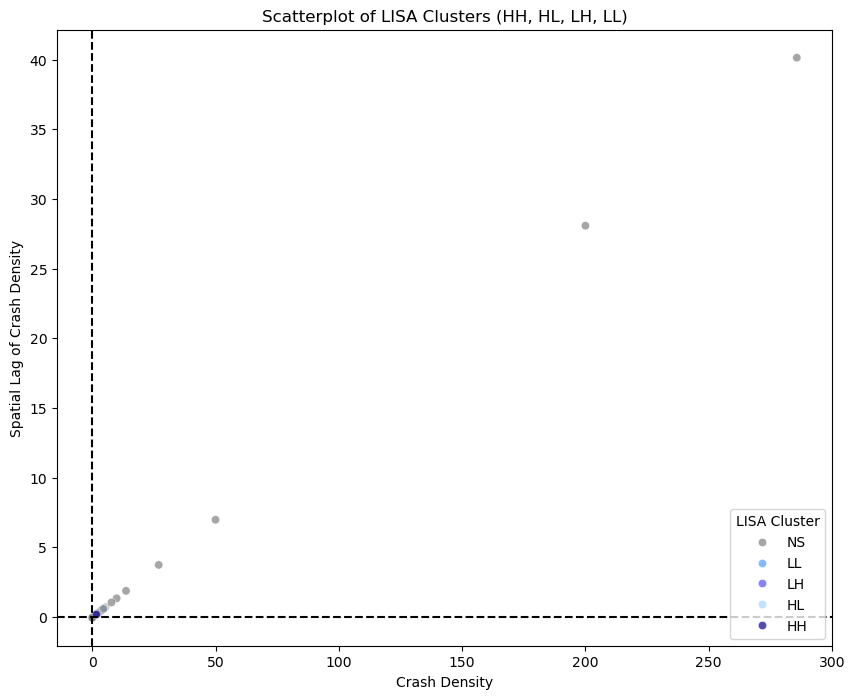

In [14]:
# Plot the scatterplot with HH, HL, LH, LL values
plt.figure(figsize=(10, 8))
sns.scatterplot(
    x=crashes_index["crash_density"],
    y=lisa.z,
    hue=crashes_index["LISA_Cluster"],
    palette={"HH": "#0a0091", "LH": "#554dff", "LL": "#4d9dff", "HL": "#a1d6ff", "NS": "gray"},
    alpha=0.7
)

plt.axhline(0, color="black", linestyle="--")
plt.axvline(0, color="black", linestyle="--")

plt.xlabel("Crash Density")
plt.ylabel("Spatial Lag of Crash Density")
plt.title("Scatterplot of LISA Clusters (HH, HL, LH, LL)")

plt.legend(title="LISA Cluster", loc="lower right")

plt.show()

### **Interpretation**
- The presence of HH and LL clusters confirms that some areas show strong spatial clustering of high or low crash densities. The Moran's I scatterplot supports this clustering trend.
- Some extreme values in crash density (points in the top right corner) suggest outliers that could be affecting the spatial patterns.

In [15]:
# Set up the base map
bounds = crashes_index.total_bounds
minx, miny, maxx, maxy = bounds
center_lat = (miny + maxy) / 2
center_lon = (minx + maxx) / 2

m_l = folium.Map(location=[center_lat, center_lon], tiles="cartodb positron")
m_l.fit_bounds([[miny, minx], [maxy, maxx]])

In [16]:
# Map visualization
lisa_colors = {
    "HH": "#0a0091",
    "LH": "#554dff",
    "LL": "#4d9dff",
    "HL": "#a1d6ff",
    "NS": "white"
}

folium.GeoJson(
    crashes_index,
    name="LISA Cluster Map",
    style_function=lambda feature: {
        "fillColor": lisa_colors.get(feature["properties"]["LISA_Cluster"], "gray"),
        "color": "white",
        "weight": 0.3,
        "fillOpacity": 0.7
    },
    tooltip=folium.GeoJsonTooltip(
        fields=["FIPS", "crash_density", "LISA_Cluster", "p-value"],
        aliases=["Census Tract", "Crash Density", "Cluster Type", "p-value"],
        localize=True
    )
).add_to(m_l)

colormap = branca.colormap.StepColormap(
    colors=list(lisa_colors.values()),  
    vmin=0, vmax=4,  
    index=[0, 1, 2, 3, 4],
    caption="LISA Cluster Types"
)
colormap.add_to(m_l)

folium.LayerControl().add_to(m_l)

### **Contribution**
- Yuxiang Wei: Data cleaning
- Yanling Sang: Global Moran's I analysis
- Jia Ni: Local Moran's analysis